# **About Data**

## **Google Play Store**
1. App :- Name of the App.
2. Category :- Category under which the App falls.
3. Rating :- Application's rating on playstore
4. Reviews :- Number of reviews of the App.
5. Size :- Size of the App.
6. Install :- Number of Installs of the App.
7. Type :- If the App is free/paid.
8. Price :- Price of the app (0 if it is Free).
9. Content Rating :- Appropiate Target Audience of the App.
10. Genres:- Genre under which the App falls.
11. Last Updated :- Date when the App was last updated.
12. Current Ver :- Current Version of the Application.
13. Android Ver :- Minimum Android Version required to run the App.

# **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Loading Dataset**

In [2]:
df=pd.read_csv('/content/drive/MyDrive/googleplaystore.csv')

In [3]:
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [4]:
df.shape

(10841, 13)

In [5]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [7]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


# **Cleaning Data**

App

In [8]:
df['App'].unique()

array(['Photo Editor & Candy Camera & Grid & ScrapBook',
       'Coloring book moana',
       'U Launcher Lite – FREE Live Cool Themes, Hide Apps', ...,
       'Parkinson Exercices FR', 'The SCP Foundation DB fr nn5n',
       'iHoroscope - 2018 Daily Horoscope & Astrology'], dtype=object)

Category

In [9]:
df['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION',
       '1.9'], dtype=object)

In [10]:
df[df['Category'] == '1.9']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [11]:
df.loc[10472] = df.loc[10472].shift()
df['App'].loc[10472] = df['Category'].loc[10472]
df['Category'].loc[10472] = "LIFESTYLE"
df.loc[10472] # shifted all the values and search for the category of this app

/tmp/ipykernel_2308/1484725682.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.9' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[10472] = df.loc[10472].shift()
/tmp/ipykernel_2308/1484725682.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.



,10472
App,Life Made WI-Fi Touchscreen Photo Frame
Category,LIFESTYLE
Rating,1.9
Reviews,19.0
Size,3.0M
Installs,"1,000+"
Type,Free
Price,0
Content Rating,Everyone
Genres,NaN


Rating

In [12]:
df['Rating'].unique()

array([4.1, 3.9, 4.7, 4.5, 4.3, 4.4, 3.8, 4.2, 4.6, 3.2, 4.0, nan, 4.8,
       4.9, 3.6, 3.7, 3.3, 3.4, 3.5, 3.1, 5.0, 2.6, 3.0, 1.9, 2.5, 2.8,
       2.7, 1.0, 2.9, 2.3, 2.2, 1.7, 2.0, 1.8, 2.4, 1.6, 2.1, 1.4, 1.5,
       1.2, '1.9'], dtype=object)

In [13]:
df['Rating'] = pd.to_numeric(df['Rating'])
df['Rating'].dtype

dtype('float64')

In [14]:
for category in df['Category'].unique():
    category_mean = df[df['Category'] == category]['Rating'].mean()
    df.loc[(df['Category'] == category) & (df['Rating'].isnull()), 'Rating'] = category_mean

print(df['Rating'].isnull().sum())

0


Reviews

In [15]:
df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [16]:
df['Reviews'] = df['Reviews'].astype(float)
df['Reviews'].dtype

dtype('float64')

Size

In [17]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [18]:
print((df['Size'] == 'Varies with device').sum())

1695


In [19]:
df['Size'] = df.Size.replace("Varies with device",np.nan)
df['Size'] = df.Size.str.replace("M","000")
df['Size'] = df.Size.str.replace("k","")
df['Size'] =df['Size'].astype(float)
mean_Size = df['Size'].mean()
df['Size'] = df['Size'].fillna(mean_Size)
df['Size'].dtype

dtype('float64')

In [20]:
df['Size'].unique()

array([1.90000000e+04, 1.40000000e+04, 8.70000000e+00, 2.50000000e+04,
       2.80000000e+00, 5.60000000e+00, 2.90000000e+04, 3.30000000e+04,
       3.10000000e+00, 2.80000000e+04, 1.20000000e+04, 2.00000000e+04,
       2.10000000e+04, 3.70000000e+04, 2.70000000e+00, 5.50000000e+00,
       1.70000000e+04, 3.90000000e+04, 3.10000000e+04, 4.20000000e+00,
       7.00000000e+00, 2.30000000e+04, 6.00000000e+00, 6.10000000e+00,
       4.60000000e+00, 9.20000000e+00, 5.20000000e+00, 1.10000000e+04,
       2.40000000e+04, 1.95772795e+04, 9.40000000e+00, 1.50000000e+04,
       1.00000000e+04, 1.20000000e+00, 2.60000000e+04, 8.00000000e+00,
       7.90000000e+00, 5.60000000e+04, 5.70000000e+04, 3.50000000e+04,
       5.40000000e+04, 2.01000000e+02, 3.60000000e+00, 5.70000000e+00,
       8.60000000e+00, 2.40000000e+00, 2.70000000e+04, 2.50000000e+00,
       1.60000000e+04, 3.40000000e+00, 8.90000000e+00, 3.90000000e+00,
       2.90000000e+00, 3.80000000e+04, 3.20000000e+04, 5.40000000e+00,
      

Installs

In [21]:
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [22]:
df['Installs'] = df.Installs.str.replace(",","")
df['Installs'] = df.Installs.str.replace("+","")
df['Installs'] = df['Installs'].astype(float)
df['Installs'].dtype

dtype('float64')

Type

In [23]:
df['Type'].unique()

array(['Free', 'Paid', nan], dtype=object)

In [24]:
df[df['Type'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9148,Command & Conquer: Rivals,FAMILY,4.192272,0.0,19577.279477,0.0,NaN,0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device


In [25]:
df['Type'] = df['Type'].fillna('Free') # searched for the app and it was Free

Price

In [26]:
df['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [27]:
df['Price'] = df.Price.str.replace("$","").astype(float)
df['Price'].dtype

dtype('float64')

Genres

In [28]:
df['Genres'].unique()

array(['Art & Design', 'Art & Design;Pretend Play',
       'Art & Design;Creativity', 'Art & Design;Action & Adventure',
       'Auto & Vehicles', 'Beauty', 'Books & Reference', 'Business',
       'Comics', 'Comics;Creativity', 'Communication', 'Dating',
       'Education;Education', 'Education', 'Education;Creativity',
       'Education;Music & Video', 'Education;Action & Adventure',
       'Education;Pretend Play', 'Education;Brain Games', 'Entertainment',
       'Entertainment;Music & Video', 'Entertainment;Brain Games',
       'Entertainment;Creativity', 'Events', 'Finance', 'Food & Drink',
       'Health & Fitness', 'House & Home', 'Libraries & Demo',
       'Lifestyle', 'Lifestyle;Pretend Play',
       'Adventure;Action & Adventure', 'Arcade', 'Casual', 'Card',
       'Casual;Pretend Play', 'Action', 'Strategy', 'Puzzle', 'Sports',
       'Music', 'Word', 'Racing', 'Casual;Creativity',
       'Casual;Action & Adventure', 'Simulation', 'Adventure', 'Board',
       'Trivia', 'Role 

In [29]:
df[df['Genres'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,LIFESTYLE,1.9,19.0,3.0,1000.0,Free,0.0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up


In [30]:
df['Genres'] = df['Genres'].fillna('Lifestyle')

Last Updated

In [31]:
df['Last Updated'].unique()

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      dtype=object)

In [32]:
df['Last Updated'] = pd.to_datetime(df['Last Updated']).dt.strftime('%m/%d/%Y')
df['Last Updated']

,Last Updated
0,01/07/2018
1,01/15/2018
2,08/01/2018
3,06/08/2018
4,06/20/2018
...,...
10836,07/25/2017
10837,07/06/2018
10838,01/20/2017
10839,01/19/2015


In [33]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [34]:
df.describe(include=['O'])

,App,Category,Type,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,10841,10841,10841,10841,10833,10839
unique,9660,33,2,6,119,1377,2831,33
top,ROBLOX,FAMILY,Free,Everyone,Tools,08/03/2018,Varies with device,4.1 and up
freq,9,1972,10041,8715,842,326,1459,2451


# **Visualizaions**

Category
FAMILY             8267.161305
GAME               4903.557338
TOOLS              3411.967847
MEDICAL            1939.573143
BUSINESS           1895.867987
PRODUCTIVITY       1785.631909
PERSONALIZATION    1699.707006
SPORTS             1621.828213
COMMUNICATION      1609.353659
LIFESTYLE          1565.679683
Name: Rating, dtype: float64


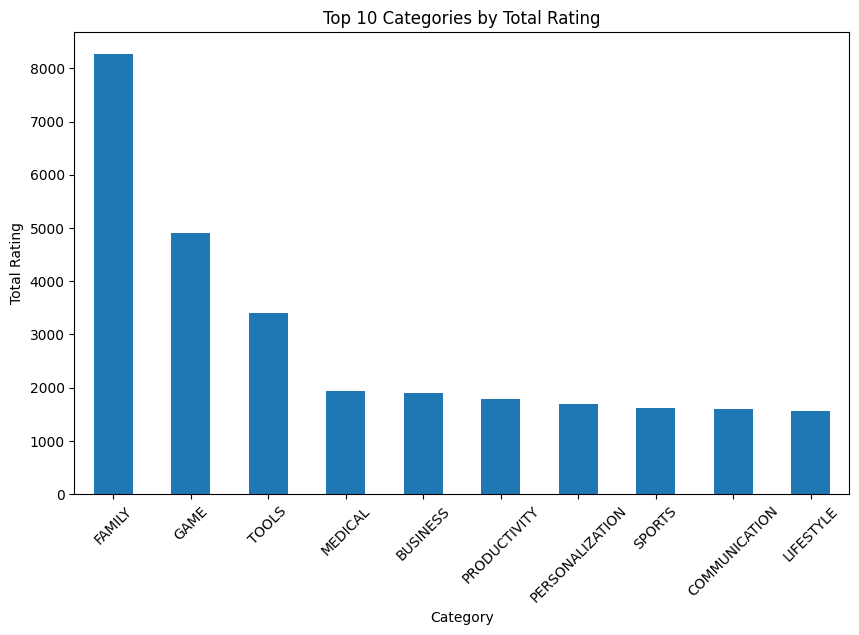

In [35]:
top_rating = (df.groupby('Category')['Rating'].sum().sort_values(ascending=False).head(10))

print(top_rating)

plt.figure(figsize=(10,6))
top_rating.plot(kind='bar')

plt.title('Top 10 Categories by Total Rating')
plt.xlabel('Category')
plt.ylabel('Total Rating')
plt.xticks(rotation=45)

plt.show()

The **FAMILY** category dominates the chart with a total rating exceeding 8,000, followed by **GAME** at nearly 5,000 and **TOOLS** at roughly 3,400. The remaining seven categories ranging from **MEDICAL** down to **LIFESTYLE** maintain a much lower stable plateau, each hovering between approximately 1,500 and 2,000 total ratings.

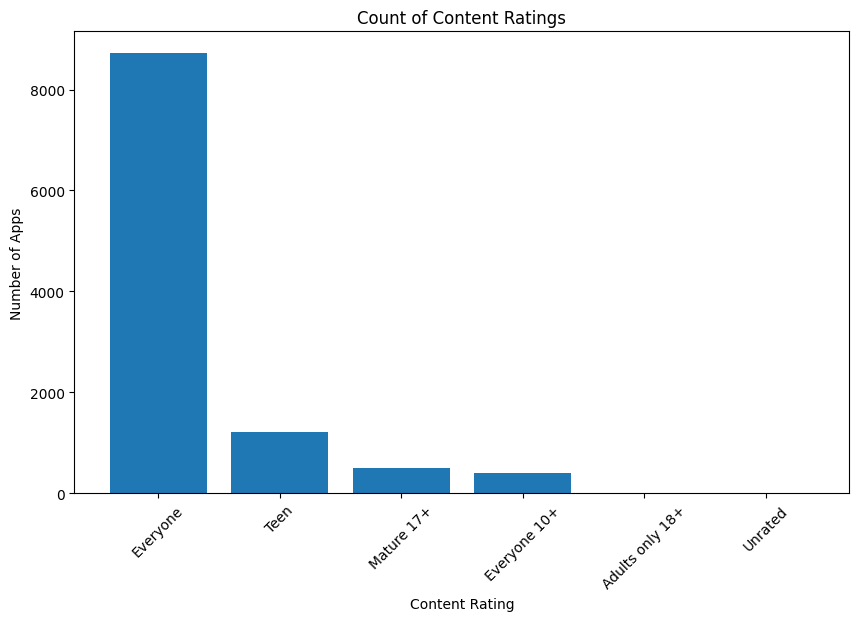

In [36]:
content_counts = df['Content Rating'].value_counts()

plt.figure(figsize=(10,6))

plt.bar(content_counts.index, content_counts.values)

plt.title('Count of Content Ratings')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')

plt.xticks(rotation=45)

plt.show()

The **Everyone** rating vastly outnumbers the rest with roughly 8,700 apps, while the second-largest category **Teen**, drops steeply to around 1,200 apps. **Mature 17+** and **Everyone 10+** make up a small fraction of the chart at approximately 500 and 400 apps, whereas **Adults only 18+** and **Unrated** are virtually non-existent on this scale.

In [37]:
pd.crosstab([df.Type],df["Content Rating"] ,margins=True)

Content Rating,Adults only 18+,Everyone,Everyone 10+,Mature 17+,Teen,Unrated,All
Type,,,,,,,
Free,3,8020,381,479,1156,2,10041
Paid,0,695,33,20,52,0,800
All,3,8715,414,499,1208,2,10841


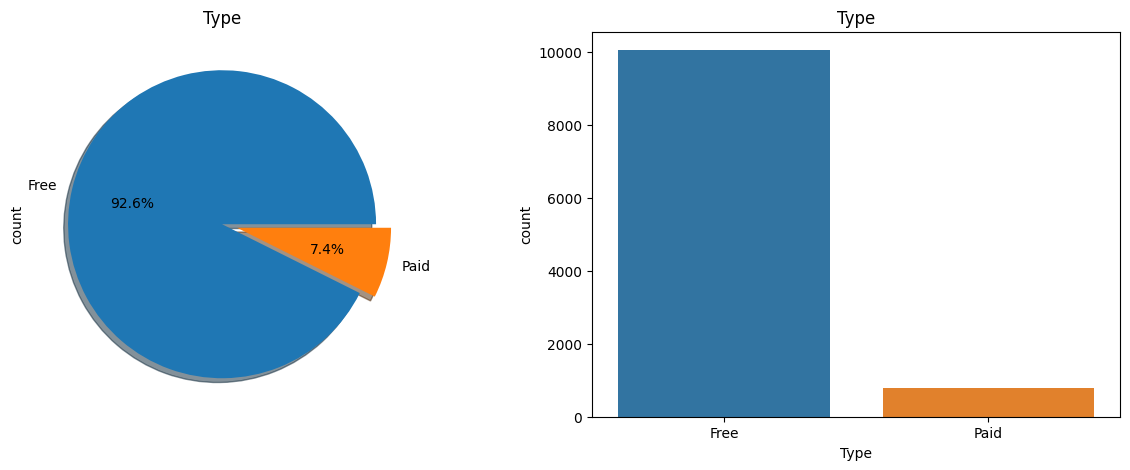

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

df['Type'].value_counts().plot.pie(explode=[0,0.1], autopct='%1.1f%%', ax=axs[0], shadow=True)
axs[0].set_title('Type')

sns.countplot(x='Type', data=df, ax=axs[1], hue='Type')
axs[1].set_title('Type')

plt.show()

On the left, a chart shows that **Free** items make up the vast majority at 92.6%, while **Paid** items represent a small slice at 7.4%. On the right, a corresponding vertical bar chart visualizes these proportions as raw volumes, showing the blue **Free** bar towering at just over 10,000 counts, contrasted against a much shorter orange **Paid** bar sitting just under 1,000 counts.

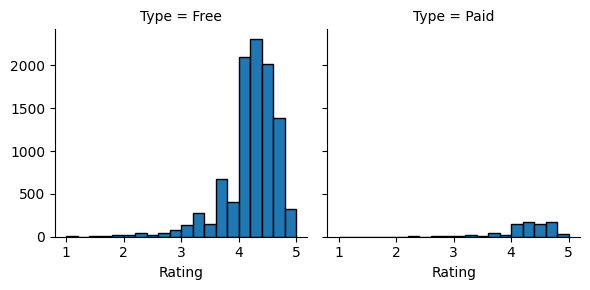

In [39]:
Type_rating_grid = sns.FacetGrid(df, col='Type')
Type_rating_grid.map(plt.hist, 'Rating', bins=20, edgecolor='black')
plt.show()

The left histogram **(Type = Free)** displays a massive volume of data that is strongly left-skewed, peaking sharply between a 4.0 and 4.2 rating with over 2,500 counts. In contrast, the right histogram **(Type = Paid)** shares the same left-skewed trend but exhibits a lower overall, with its highest peak just hovering around the 200-count mark near a 4.0 rating.

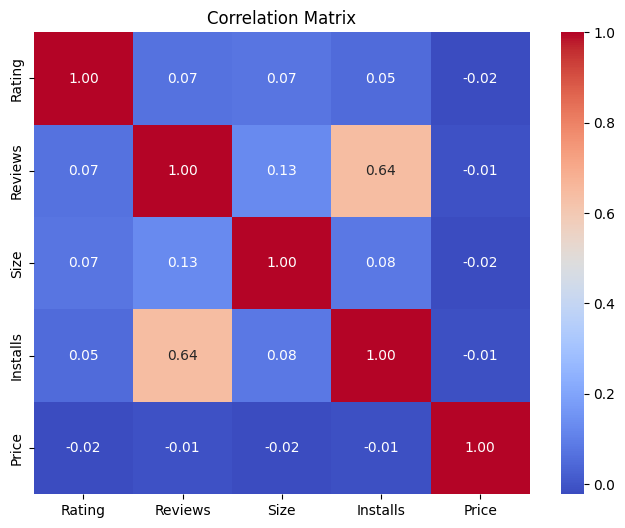

In [40]:
numeric_cols = ['Rating', 'Reviews', 'Size', 'Installs', 'Price']

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

The diagonal blocks from the top-left to the bottom-right are all dark red with a value of 1.00, representing each variable's perfect correlation with itself. Off the diagonal, the strongest relationship shown is a positive correlation of 0.64 between **Installs** and **Reviews**, while all other variable pairings show near-zero or slightly negative values (between -0.02 and 0.13), indicating virtually no relationship between them.

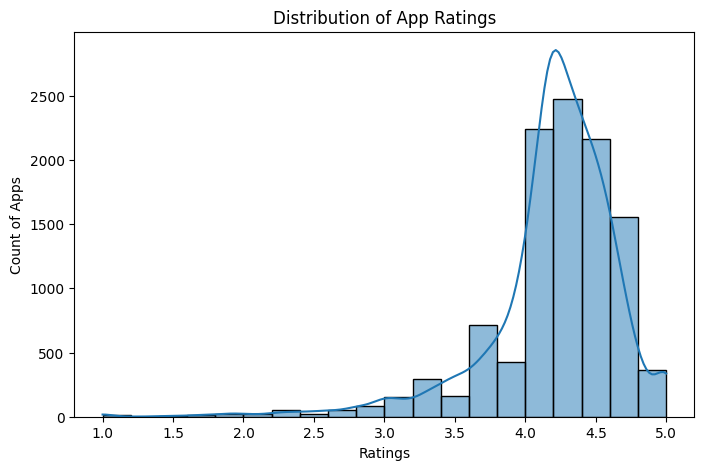

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df['Rating'], bins=20, kde=True)

plt.title('Distribution of App Ratings')
plt.xlabel('Ratings')
plt.ylabel('Count of Apps')

plt.show()

The data is left-skewed, indicating that most apps receive high ratings on the 1.0 to 5.0 scale. The highest concentration of apps sits in the 4.0 to 4.2 bin, which peaks dramatically with a count of around 2,700 apps. Subsequent bins between 4.2 and 4.8 also show high volumes, remaining well above 1,500 apps each, before dropping off as ratings approach a perfect 5.0. Apps with ratings below 3.5 are quite rare, with counts consistently trailing off toward zero on the left side of the chart.